<a href="https://colab.research.google.com/github/njakusi0-rgb/CIFAKE-image-detection-model-/blob/main/CIFAKE%20image%20detection%20model%2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# We are import Keras and Tensorflow which Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:

# Loading CIFAKE Dataset from downloaded path
# The dataset contains real and AI-generated synthetic images
# Images are colored(RGB), and of 32 x 32 pixels
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [ ]:

# Define dataset directories
train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

# Create ImageDataGenerator for loading and preprocessing images
datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(32, 32),
    batch_size=32,
    class_mode='binary',  # Binary classification: real vs fake
    shuffle=True
)

# Load test data
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(32, 32),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


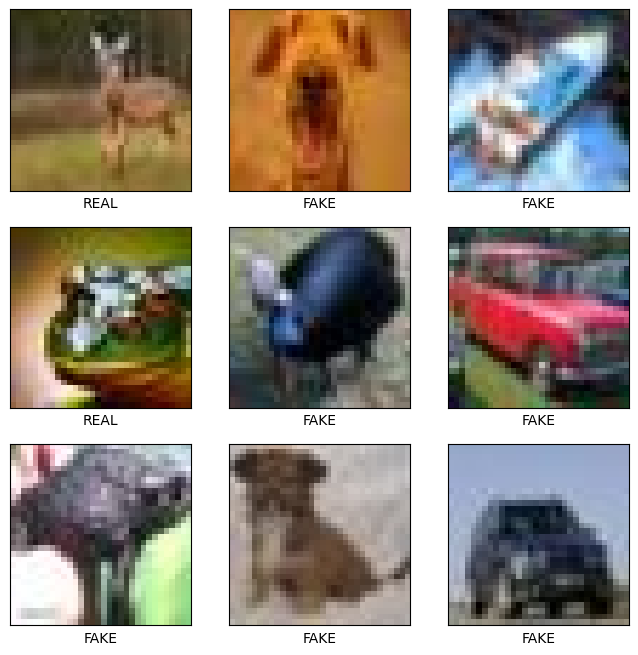

In [ ]:
# Step 4:
# CIFAKE has 2 classes: REAL and FAKE
class_names = ['REAL', 'FAKE']

# Display some sample images
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([]); plt.yticks([])
    plt.grid(False)

    # Get a batch of images
    images, labels = next(train_generator)
    plt.imshow(images[i])
    plt.xlabel(class_names[int(labels[i])])
plt.show()

In [ ]:
# Step 5:
# This is the Convolutional Layer Responsible for Feature Extraction
# We use the filters and max pooling
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu')
])

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))  # Binary classification - 1 output with sigmoid

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,985 (476.50 KB)

 Trainable params: 121,985 (476.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 6:
# Here we are training the model with the CIFAKE images
# training is done by reducing the loss and increasing the accuracy using
model.compile(optimizer='adam',
              loss='binary_crossentropy',  # Binary classification loss
              metrics=['accuracy'])

# Calculate steps per epoch for training and validation
train_steps = train_generator.samples // train_generator.batch_size
test_steps = test_generator.samples // test_generator.batch_size

history = model.fit(
    train_generator,
    epochs=10,
    steps_per_epoch=train_steps,
    validation_data=test_generator,
    validation_steps=test_steps
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1054s 337ms/step - accuracy: 0.7920 - loss: 0.4269 - val_accuracy: 0.9001 - val_loss: 0.2413
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 288s 92ms/step - accuracy: 0.9023 - loss: 0.2361 - val_accuracy: 0.9186 - val_loss: 0.2036
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 295s 95ms/step - accuracy: 0.9190 - loss: 0.2013 - val_accuracy: 0.9175 - val_loss: 0.2030
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 315s 101ms/step - accuracy: 0.9291 - loss: 0.1779 - val_accuracy: 0.9200 - val_loss: 0.2010
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 301s 96ms/step - accuracy: 0.9373 - loss: 0.1587 - val_accuracy: 0.9244 - val_loss: 0.1965
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 322s 96ms/step - accuracy: 0.9407 - loss: 0.1478 - val_accuracy: 0.9331 - val_loss: 0.1742
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 302s 97ms/step - accuracy: 0.9458 - loss: 0.1386 - val_accuracy: 0.9374 - val_loss: 0.1605
Epoch 8/10
2736/3125 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy

In [ ]:
Step 7:
test_loss, test_acc = model.evaluate(test_generator, verbose=2)
print(f'\n Test accuracy: {test_acc:.2f}')

plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Step 8:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Softmax
from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def predict_new_image(model, img_path):
    """
    Predicts whether an image is REAL or FAKE using a trained CNN model.

    Parameters:
        model: Trained TensorFlow/Keras CNN model
        img_path: Path to the image file
    """
    try:
        # Load and preprocess the image
        img = Image.open(img_path).resize((32, 32))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict the class
        prediction = model.predict(img_array)
        predicted_class = int(prediction[0][0] > 0.5)  # Threshold at 0.5 for binary classification
        confidence = prediction[0][0] if predicted_class == 1 else 1 - prediction[0][0]

        # Display results
        print("\n Image Path:", img_path)
        print("Predicted Class:", class_names[predicted_class])
        print(f" Confidence: {confidence*100:.2f}%")

        plt.imshow(img)
        plt.title(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}%)")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print("Error:", e)

In [ ]:
# Step 9:
# Example usage (you'll need to provide actual image paths):
# predict_new_image(model, "path_to_real_image.jpg")
# predict_new_image(model, "path_to_fake_image.jpg")